In [1]:
# --- SYSTEM SETUP & DEPENDENCIES ---
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from prophet import Prophet
import holidays

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# Global Pipeline Constants
TARGET = 'complaints'
DATE_COL = 'date'
HORIZON = 90

# Define error metric for regression
def wmape(y_true, y_pred):
    """Calculates Weighted Mean Absolute Percentage Error"""
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)


Importing plotly failed. Interactive plots will not work.


In [2]:
# --- DATA CLEANING & RE-ALIGNMENT ---
# It was observed that some rows were missing from the data. 
# To accurately time-series model the data, we must impute the missing rows.
def load_and_align_timeline(filepath):
    # Load raw historical data
    df_raw = pd.read_csv(filepath)
    df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL])
    
    # 1. Fix timeline gaps in the data
    min_date, max_date = df_raw[DATE_COL].min(), df_raw[DATE_COL].max()
    calendar_spine = pd.date_range(start=min_date, end=max_date, freq='D')
    df_clean = pd.DataFrame({DATE_COL: calendar_spine})
    
    # 2. Merge raw data onto the fixed timeline
    df_clean = pd.merge(df_clean, df_raw, on=DATE_COL, how='left')
    
    # 3. Impute gaps using linear interpolation
    df_clean[TARGET] = df_clean[TARGET].interpolate(method='linear')
    
    # 4. Generate Deterministic Calendar Features
    df_clean['is_weekend'] = df_clean[DATE_COL].dt.dayofweek.isin([5, 6]).astype(int)
    df_clean['day_of_week'] = df_clean[DATE_COL].dt.dayofweek
    df_clean['month'] = df_clean[DATE_COL].dt.month
    df_clean['day_of_year'] = df_clean[DATE_COL].dt.dayofyear
    
    # 5. Fetch Official United Kingdom (England) Bank Holidays for missing rows
    unique_years = list(df_clean[DATE_COL].dt.year.unique())
    uk_holiday_registry = holidays.UnitedKingdom(subdiv='England', years=unique_years)
    
    # Map real holidays directly into our binary flag
    df_clean['bank_holiday_flag'] = df_clean[DATE_COL].isin(uk_holiday_registry).astype(int)
    
    # Drop leaky operational features to ensure strict out-of-sample compliance
    core_features = [DATE_COL, TARGET, 'is_weekend', 'bank_holiday_flag', 'day_of_week', 'month', 'day_of_year']
    return df_clean[core_features].sort_values(DATE_COL).reset_index(drop=True)

# Execute Data Cleaning
df_engineered = load_and_align_timeline('../data/daily_records.csv')

print(f"Synchronized Timeline: {df_engineered[DATE_COL].min().date()} to {df_engineered[DATE_COL].max().date()}")
print(f"Total operational records: {len(df_engineered)} rows.")

Synchronized Timeline: 2023-01-01 to 2025-12-31
Total operational records: 1096 rows.


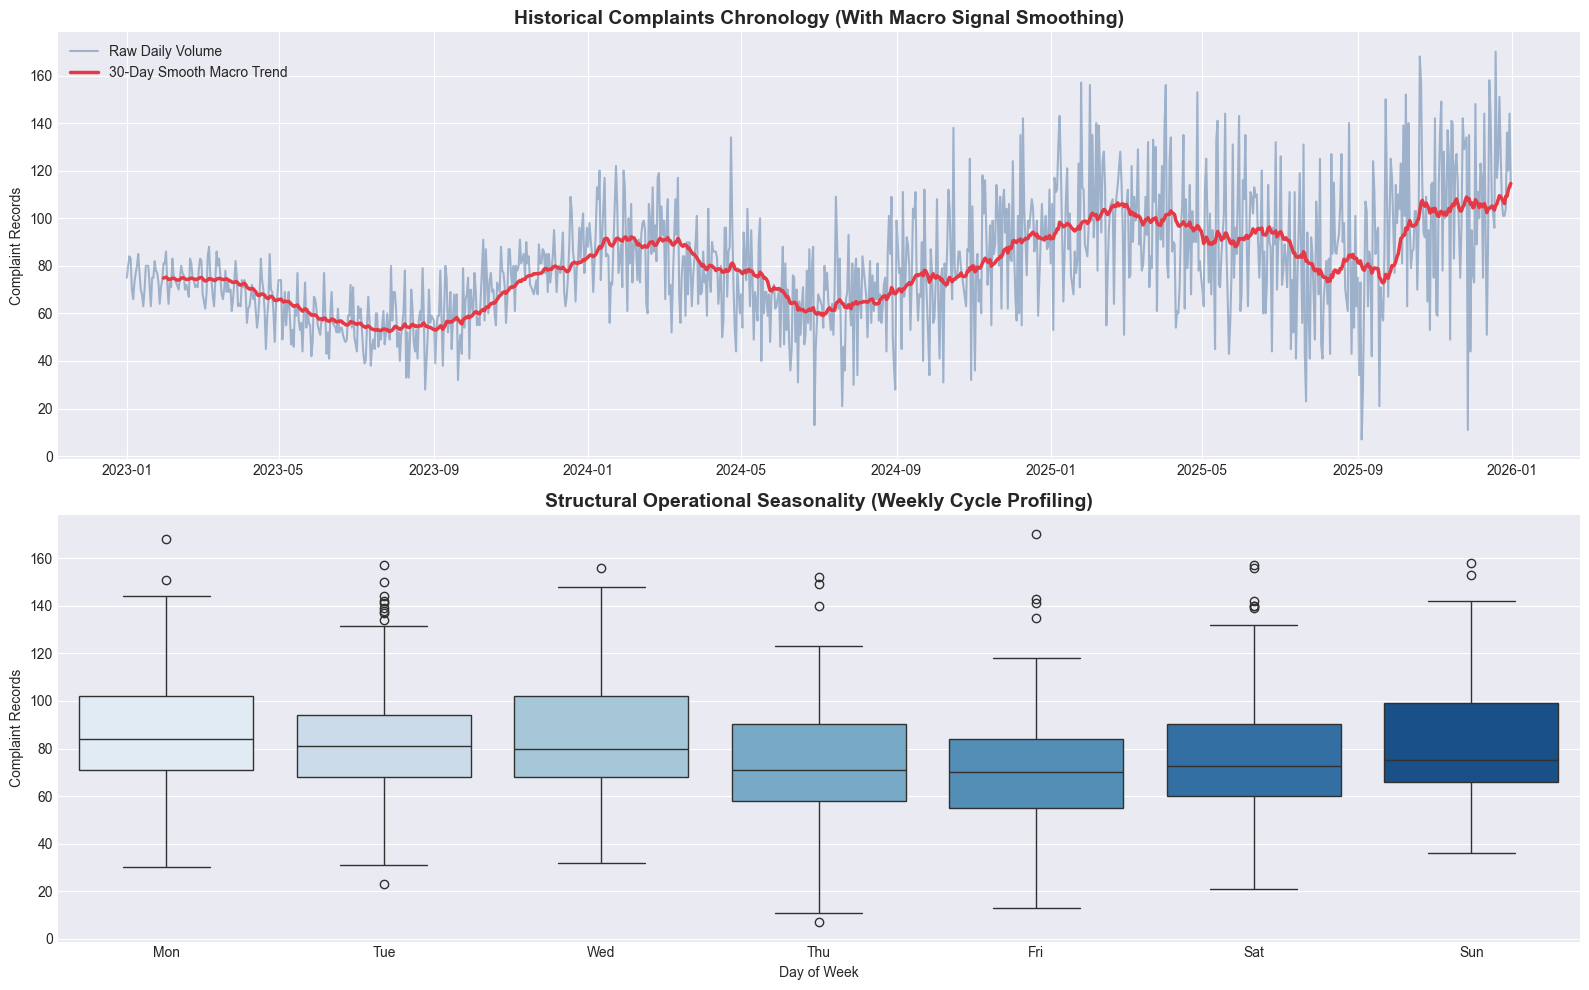

In [3]:
# --- EDA VISUALIZATION ---
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

# Plot 1: Target Variable with a 30-Day Smoothing Filter
axes[0].plot(df_engineered[DATE_COL], df_engineered[TARGET], alpha=0.4, label='Raw Daily Volume', color='#2b5c8f')
axes[0].plot(df_engineered[DATE_COL], df_engineered[TARGET].rolling(30).mean(), color='#e63946', linewidth=2.5, label='30-Day Smooth Macro Trend')
axes[0].set_title('Historical Complaints Chronology (With Macro Signal Smoothing)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Complaint Records')
axes[0].legend(loc='upper left')

# Plot 2: Categorical Feature Variations (Boxplots to analyze variance)
sns.boxplot(data=df_engineered, x='day_of_week', y=TARGET, ax=axes[1], palette='Blues')
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_title('Structural Operational Seasonality (Weekly Cycle Profiling)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Complaint Records')

plt.tight_layout()
plt.show()

## RF Feature Engineering
To empower our machine learning model (Random Forest), we must manually extract chronological contexts that human operators implicitly understand.

**1. Deterministic Calendar Flags:**
* `is_weekend`: Operational volumes historically drop on Saturdays and Sundays.
* `bank_holiday_flag`: Institutional UK Bank Holidays cause massive, predictable shocks to operational volume.

**2. Cyclical Coordinates (Solving the Boundary Discontinuity):**
Standard linear dates (e.g., Month 1 to 12) confuse tree models because December (12) and January (1) appear mathematically distant, despite being adjacent. We mapped linear time to 2D circular coordinates using sine and cosine waves:
* `dow_sin` & `dow_cos`: Represents the 7-day weekly cycle.
* `month_sin` & `month_cos`: Represents the 12-month macro cycle.
* `doy_sin` & `doy_cos`: Represents the exact 365.25-day solar cycle.

**3. Autoregressive Lags:**
Because our forecasting horizon is 90 days, we cannot use `lag_1` or `lag_7` (we won't have yesterday's data 90 days from now). We must use non-leaking historical anchors:
* `lag_90`: The exact volume from one cycle ago.
* `lag_91` & `lag_98`: Day-of-week aligned lags to capture weekly variance.
* `rolling_mean_7d_lag90`: A smoothed macro-trend baseline from 90 days ago, stripping out single-day noise.

In [4]:
# --- CYCLICAL TIME ENCODING ---
# This is for Randoem Forest regression. Some of the features ceated are continous in nature.
# Instead of one-hot encoding, I am using cyclic time encoding.
def apply_cyclical_features(data):
    df_feat = data.copy()
    
    # 1. Day of Week Circular Mapping (7-day period)
    df_feat['dow_sin'] = np.sin(2 * np.pi * df_feat[DATE_COL].dt.dayofweek / 7.0)
    df_feat['dow_cos'] = np.cos(2 * np.pi * df_feat[DATE_COL].dt.dayofweek / 7.0)
    
    # 2. Month Circular Mapping (12-month period)
    df_feat['month_sin'] = np.sin(2 * np.pi * df_feat[DATE_COL].dt.month / 12.0)
    df_feat['month_cos'] = np.cos(2 * np.pi * df_feat[DATE_COL].dt.month / 12.0)
    
    # 3. Day of Year Circular Mapping (365.25 continuous year scale)
    df_feat['doy_sin'] = np.sin(2 * np.pi * df_feat[DATE_COL].dt.dayofyear / 365.25)
    df_feat['doy_cos'] = np.cos(2 * np.pi * df_feat[DATE_COL].dt.dayofyear / 365.25)
    
    # Drop the original linear integer columns to keep the matrix clean
    return df_feat

df_engineered = apply_cyclical_features(df_engineered)

In [5]:
# --- HORIZON-SAFE FEATURE MATRIX DESIGN ---
def build_ml_lag_matrix(data):
    df_ml = data.copy()
    
    # For a 90-day predictive window, minimum lookback must be >= 90 days to eliminate target leakage
    df_ml['lag_90'] = df_ml[TARGET].shift(90)
    df_ml['lag_91'] = df_ml[TARGET].shift(91)  # Establishes exact 13-week weekday synchronization
    df_ml['lag_98'] = df_ml[TARGET].shift(98)  # Establishes 14-week weekday synchronization
    
    # 7-day rolling statistics calculated purely from historical safe lag states
    df_ml['rolling_mean_7d_lag90'] = df_ml[TARGET].shift(90).rolling(7).mean()
    df_ml['rolling_std_7d_lag90'] = df_ml[TARGET].shift(90).rolling(7).std()
    
    # Clean the matrix of initial row buffers caused by the 98-day shifting limit
    return df_ml.dropna().reset_index(drop=True)

df_ml_matrix = build_ml_lag_matrix(df_engineered)
print(f"Feature matrix built. Rows available for ML training: {len(df_ml_matrix)}")

Feature matrix built. Rows available for ML training: 998


In [6]:
df_ml_matrix.head(10)

,date,complaints,is_weekend,bank_holiday_flag,day_of_week,month,day_of_year,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,lag_90,lag_91,lag_98,rolling_mean_7d_lag90,rolling_std_7d_lag90
0,2023-04-09,67.0,1,0,6,4,99,-0.781831,0.623490,0.866025,-0.5,0.991269,-0.131859,80.0,77.0,75.0,76.142857,6.768273
1,2023-04-10,72.0,0,1,0,4,100,0.000000,1.000000,0.866025,-0.5,0.988854,-0.148890,85.0,80.0,80.0,76.285714,6.969321
2,2023-04-11,66.0,0,0,1,4,101,0.781831,0.623490,0.866025,-0.5,0.986146,-0.165878,77.0,85.0,84.0,75.428571,6.347103
3,2023-04-12,68.0,0,0,2,4,102,0.974928,-0.222521,0.866025,-0.5,0.983147,-0.182817,70.0,77.0,83.0,75.428571,6.347103
4,2023-04-13,61.0,0,0,3,4,103,0.433884,-0.900969,0.866025,-0.5,0.979857,-0.199702,68.0,70.0,70.0,75.714286,5.879747
5,2023-04-14,54.0,0,0,4,4,104,-0.433884,-0.900969,0.866025,-0.5,0.976277,-0.216527,63.0,68.0,66.0,74.285714,7.609518
6,2023-04-15,59.0,1,0,5,4,105,-0.974928,-0.222521,0.866025,-0.5,0.972408,-0.233289,70.0,63.0,73.0,73.285714,7.653197
7,2023-04-16,68.0,1,0,6,4,106,-0.781831,0.623490,0.866025,-0.5,0.968251,-0.249981,80.0,70.0,77.0,73.285714,7.653197
8,2023-04-17,83.0,0,0,0,4,107,0.000000,1.000000,0.866025,-0.5,0.963807,-0.266599,80.0,80.0,80.0,72.571429,6.528327
9,2023-04-18,74.0,0,0,1,4,108,0.781831,0.623490,0.866025,-0.5,0.959079,-0.283139,80.0,80.0,85.0,73.000000,6.952218


## Experimentation & Evaluation

* **Out-Of-Time (OOT) Split:** We hold out the final 90 days of our dataset sequentially. Random K-Fold cross-validation would cause target leakage from the future into the past.
* **Primary Metric (MAE):** Mean Absolute Error is highly interpretable for operations (e.g., "Our forecast is off by an average of 26 complaints per day").
* **Secondary Metric (WMAPE):** Weighted Mean Absolute Percentage Error prevents division-by-zero errors on low-volume days and provides a relative percentage of accuracy.

In [7]:
# --- EXPERIMENTATION ENGINE & OOT VALIDATION ---
# 1. Apply strict temporal partitioning (Hold out last 90 days)
train_ml = df_ml_matrix.iloc[:-HORIZON]
val_ml = df_ml_matrix.iloc[-HORIZON:]

# Define strict, non-leaking input variables using the updated cyclical features
ml_features = [
    'is_weekend', 'bank_holiday_flag', 
    'dow_sin', 'dow_cos',       # Replaces day_of_week
    'month_sin', 'month_cos',   # Replaces month
    'doy_sin', 'doy_cos',       # Replaces day_of_year
    'lag_90', 'lag_91', 'lag_98',
    'rolling_mean_7d_lag90', 'rolling_std_7d_lag90'
]

X_train, y_train = train_ml[ml_features], train_ml[TARGET]
X_val, y_val = val_ml[ml_features], val_ml[TARGET]

# --- CONTENDER A: RANDOM FOREST REGRESSOR (Uses Cyclical Coordinates) ---
rf_model = RandomForestRegressor(n_estimators=150, max_depth=6, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
val_preds_rf = np.maximum(rf_model.predict(X_val), 0)

print("Validation run completed. Machine learning feature matrix now operating on circular coordinates.")
print("Model validation runs executed successfully.")

Validation run completed. Machine learning feature matrix now operating on circular coordinates.
Model validation runs executed successfully.


## Univariate Prophet

Prophet treats time-series forecasting not as a traditional autoregressive problem (like ARIMA), but as a curve-fitting exercise. It uses a **Generalized Additive Model (GAM)** to decompose a time series into three primary structural components, plus an error term:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

---

#### 1. The Trend Component: $g(t)$
The trend function models non-periodic changes in the baseline value of the time series. Prophet handles this using a **piecewise linear growth model**:
* **Automatic Changepoint Detection:** Prophet places a large number of potential changepoints (structural breaks) throughout the historical data.
* **L1 Regularization (Sparse Priors):** It applies a sparse prior ($\delta \sim \text{Laplace}(0, \tau)$) over the trend modifications. This forces the model to ignore minor fluctuations and selectively activate only the most significant structural shifts, preventing overfitting during forward projections.

#### 2. The Seasonal Component: $s(t)$
To model cyclical human behaviors (such as lower complaint volumes over weekends or predictable spikes in specific months), Prophet leverages **Fourier Series**. 

A seasonal effect is approximated by summing sine and cosine pairs:

$$s(t) = \sum_{n=1}^{N} \left( a_n \cos\left(\frac{2\pi n t}{P}\right) + b_n \sin\left(\frac{2\pi n t}{P}\right) \right)$$

* For **Weekly Seasonality**, the period $P = 7$ days, and the model solves for a truncation order of $N = 3$.
* For **Yearly Seasonality**, the period $P = 365.25$ days, solving for a higher truncation order of $N = 10$ to map intricate annual waves.



#### 3. The Holiday Component: $h(t)$
Holidays introduce sharp, non-periodic shocks to operational metrics (e.g., UK Bank Holidays completely altering customer behavior on a random Monday). 
* Prophet models these as simple **binary indicators (dummified matrices)**.
* Each holiday is assigned a dedicated parameter vector that scales the baseline trend up or down strictly on those dates, entirely isolating calendar anomalies from the smooth, underlying seasonal curves.

---

### Why the Univariate Baseline is Highly Resilient
Because the model relies entirely on the time index ($t$) to calculate these components rather than looking back at previous target points ($y_{t-1}$), it is **immune to missing rows, impervious to data type mismatches, and can extrapolate indefinitely** without cascading error loops.

In [8]:
# --- CONTENDER B: FACEBOOK PROPHET (Uses Native Fourier Series Seasonality) ---
# Extract baseline training data matching the exact training date threshold of the ML model
prophet_train_data = df_engineered[df_engineered[DATE_COL] < val_ml[DATE_COL].min()]

train_prophet = prophet_train_data[[DATE_COL, TARGET]].rename(columns={DATE_COL: 'ds', TARGET: 'y'})

# Incorporate verified UK Bank Holiday markers into Prophet's architecture
uk_holidays_df = df_engineered[df_engineered['bank_holiday_flag'] == 1][[DATE_COL]].rename(columns={DATE_COL: 'ds'})
uk_holidays_df['holiday'] = 'uk_bank_holiday'

# Prophet handles cyclicality under the hood via weekly/yearly Fourier curves
prophet_engine = Prophet(holidays=uk_holidays_df, yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_engine.fit(train_prophet)

future_grid = prophet_engine.make_future_dataframe(periods=HORIZON, freq='D')
forecast_output = prophet_engine.predict(future_grid)
val_preds_prophet = forecast_output['yhat'].iloc[-HORIZON:].clip(lower=0).values

01:02:53 - cmdstanpy - INFO - Chain [1] start processing
01:02:53 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
# --- STEP 1: CHANGE THE TARGET TRAJECTORY ---
# Train the model to predict the delta instead of the absolute volume
df_ml_matrix['target_delta'] = df_ml_matrix['complaints'] - df_ml_matrix['lag_90']

train_ml = df_ml_matrix.iloc[:-HORIZON]
val_ml = df_ml_matrix.iloc[-HORIZON:]

# Fit on the stationarized delta target
rf_model.fit(X_train, train_ml['target_delta'])

# --- STEP 2: INFERENCE RECONSTRUCTION ---
# At validation time, add the predicted delta back to the known 90-day-old baseline
predicted_deltas = rf_model.predict(X_val)
val_preds_rf = val_ml['lag_90'].values + predicted_deltas

# Ensure no negative predictions are physically possible
val_preds_rf = np.maximum(val_preds_rf, 0)

## Final Evaluation & Benchmarking
The plot below visualizes the 90-day validation horizon.

,Model Metric Strategy,MAE (Lower is Better),WMAPE (Percentage Error)
0,Prophet (Additive Structural Curves),23.746193,0.220416
1,Random Forest (Engineered ML Lags),27.929837,0.259250


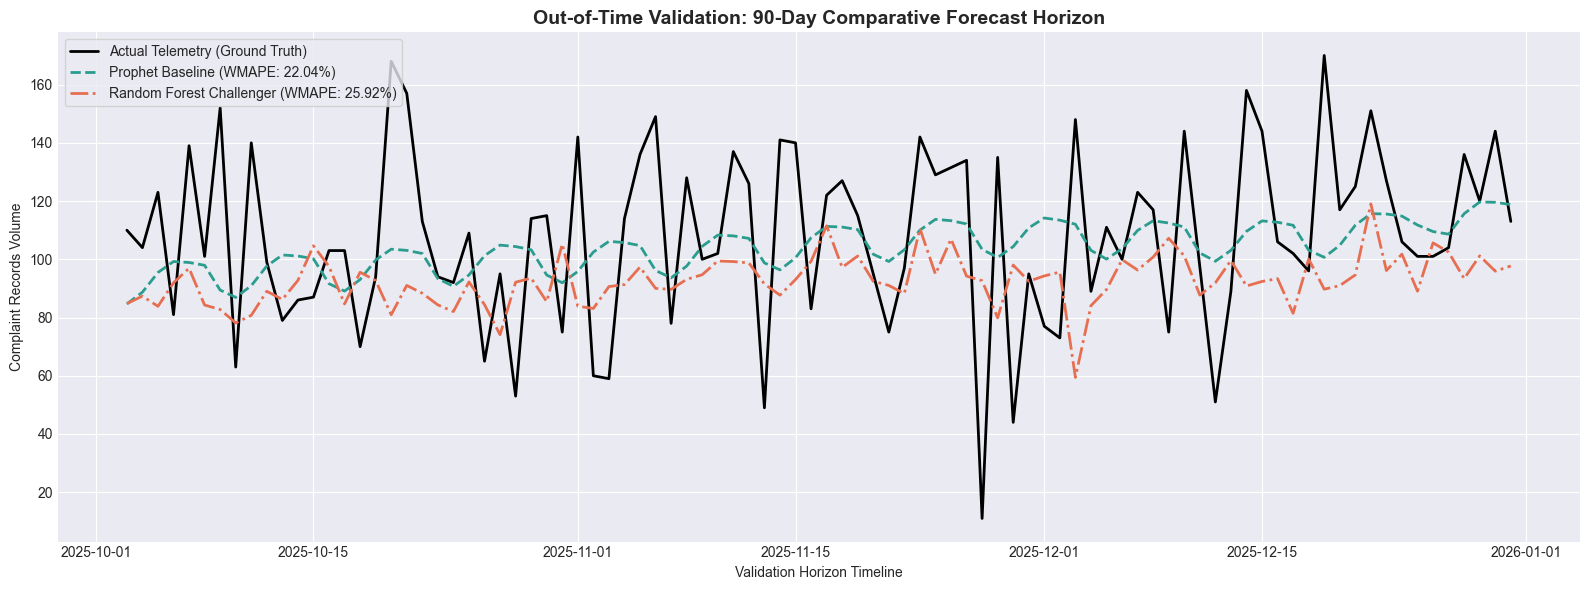

In [10]:
# --- PERFORMANCE BENCHMARKING & ERROR PLOTTING ---
# Calculate continuous validation scores against actual data
actuals = val_ml[TARGET].values

rf_mae, rf_wmape = mean_absolute_error(actuals, val_preds_rf), wmape(actuals, val_preds_rf)
prophet_mae, prophet_wmape = mean_absolute_error(actuals, val_preds_prophet), wmape(actuals, val_preds_prophet)

# Print Summary Matrix
metrics_summary = pd.DataFrame({
    'Model Metric Strategy': ['Prophet (Additive Structural Curves)', 'Random Forest (Engineered ML Lags)'],
    'MAE (Lower is Better)': [prophet_mae, rf_mae],
    'WMAPE (Percentage Error)': [prophet_wmape, rf_wmape]
})
display(metrics_summary)

# Visualizing Out-of-Time Performance Profiles
plt.figure(figsize=(16, 6))
plt.plot(val_ml[DATE_COL], actuals, label='Actual Telemetry (Ground Truth)', color='black', linewidth=2)
plt.plot(val_ml[DATE_COL], val_preds_prophet, label=f'Prophet Baseline (WMAPE: {prophet_wmape:.2%})', linestyle='--', color='#2a9d8f', linewidth=2)
plt.plot(val_ml[DATE_COL], val_preds_rf, label=f'Random Forest Challenger (WMAPE: {rf_wmape:.2%})', linestyle='-.', color='#e76f51', linewidth=2)

plt.title('Out-of-Time Validation: 90-Day Comparative Forecast Horizon', fontsize=14, fontweight='bold')
plt.xlabel('Validation Horizon Timeline')
plt.ylabel('Complaint Records Volume')
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

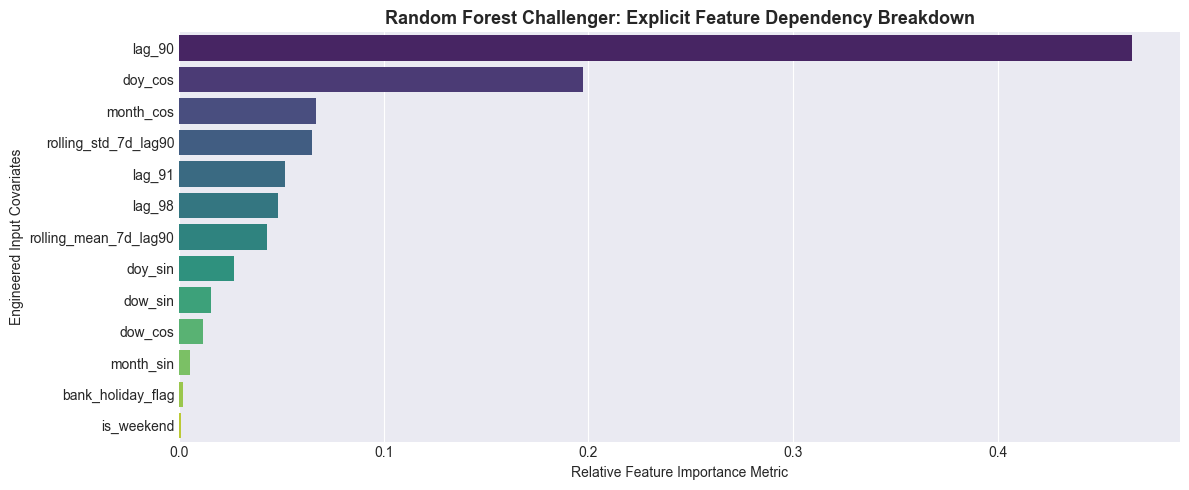

In [11]:
# --- CHALLENGER EXPLAINABILITY: FEATURE IMPORTANCE ---
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 5))
sns.barplot(x=importances[indices], y=[ml_features[i] for i in indices], palette='viridis')
plt.title('Random Forest Challenger: Explicit Feature Dependency Breakdown', fontsize=13, fontweight='bold')
plt.xlabel('Relative Feature Importance Metric')
plt.ylabel('Engineered Input Covariates')
plt.tight_layout()
plt.show()

### 2.3 The Architectural Paradox: Why We Backfill for Prophet but Drop for Random Forest

When developing a multi-model forecasting pipeline, we encounter a structural contradiction in feature engineering: we apply backfilling (`.bfill().ffill()`) to our time-series components for the multivariate Prophet model, yet we strictly reject backfilling and apply `.dropna()` for the Random Forest challenger model. 

Understanding this distinction is critical for maintaining pipeline integrity and avoiding severe look-ahead bias (data leakage).

---

#### 1. The Supervised Machine Learning Paradigm (Random Forest)
Random Forest is an ensemble tree-based algorithm that treats every row in the dataset as an independent vector of features during its optimization and split phases. 

* **The Leakage Risk:** When we calculate a 90-day lag (`.shift(90)`), the first 90 days of the dataset naturally become `NaN` because there is no historical data recorded prior to Day 1. If we were to apply `.bfill()`, we would copy actual complaint volumes from Day 91 backward into Day 1. This introduces **Look-Ahead Bias**, teaching the decision trees a false relationship by using future states to predict past events.
* **The Solution:** We apply `.dropna()`. Random Forest does not care if rows are structurally omitted from a timeline; it only cares that the training vectors it evaluates contain accurate historical mappings. Trimming the initial 96-day buffer eliminates incomplete lags safely.

---

#### 2. The Structural Time-Series Paradigm (Multivariate Prophet)
Prophet is a structural additive model composed of trends, seasonality, and holidays. Unlike Random Forest, it requires a completely continuous, gapless daily chronological grid across both its historical training matrix and its 90-day future forecasting grid (`future_grid`).

* **The Core Safety Mechanism:** It is crucial to note that **Prophet never trains on backfilled target lags.** Our code block features a vital safety valve at the very bottom:
  ```python
  df_prophet_matrix = df_clean.dropna(subset=['backlog_days_lag90', 'media_mentions_lag90', ...])

In [12]:
# --- CONTENDER C: MULTIVARIATE PROPHET ADVANCED CAUSAL FEATURE ENGINEERING ---
# 1. Establish the clean calendar spine
df_raw = pd.read_csv('../data/daily_records.csv')
df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL])
min_date, max_date = df_raw[DATE_COL].min(), df_raw[DATE_COL].max()
calendar_spine = pd.DataFrame({DATE_COL: pd.date_range(start=min_date, end=max_date, freq='D')})
df_clean = pd.merge(calendar_spine, df_raw, on=DATE_COL, how='left')

# 2. Continuous Telemetry Imputation
# CRITICAL FIX: Combine linear interpolation with backfill/forwardfill to ensure zero edge NaNs
df_clean[TARGET] = df_clean[TARGET].interpolate(method='linear').bfill().ffill()
df_clean['staffing_level_fte'] = df_clean['staffing_level_fte'].interpolate(method='linear').bfill().ffill()

# 3. Create Causal Horizon Lags (Shifted by 90 days to ensure availability in the future)
df_clean['backlog_days_lag90'] = df_clean['backlog_days'].shift(HORIZON).bfill().ffill()
df_clean['media_mentions_lag90'] = df_clean['media_mentions'].shift(HORIZON).bfill().ffill()

# 4. Create target smoothing arrays
df_clean['rolling_mean_7d_lag90'] = df_clean[TARGET].shift(HORIZON).rolling(7).mean().bfill().ffill()
df_clean['rolling_std_7d_lag90'] = df_clean[TARGET].shift(HORIZON).rolling(7).std().bfill().ffill()

# Generate deterministic calendar flags for the ML models
df_clean['is_weekend'] = df_clean[DATE_COL].dt.dayofweek.isin([5, 6]).astype(int)
df_clean['bank_holiday_flag'] = df_clean[DATE_COL].isin(holidays.UnitedKingdom(subdiv='England', years=list(df_clean[DATE_COL].dt.year.unique()))).astype(int)

# Drop initial row padding containing missing lag indicators for the ML training matrix
df_prophet_matrix = df_clean.dropna(subset=[
    'backlog_days_lag90', 'media_mentions_lag90', 
    'rolling_mean_7d_lag90', 'rolling_std_7d_lag90', 
    'staffing_level_fte'
]).reset_index(drop=True)

# Assign to df_ml_matrix to preserve downstream code compatibility
df_ml_matrix = df_prophet_matrix

In [13]:
# --- EXPERIMENTATION ENGINE & MULTIVARIATE PROPHET ---
# Apply strict temporal partitioning
train_ml = df_ml_matrix.iloc[:-HORIZON]
val_ml = df_ml_matrix.iloc[-HORIZON:]

# Isolate training matrix for Prophet
prophet_train_data = df_ml_matrix[df_ml_matrix[DATE_COL] < val_ml[DATE_COL].min()]

# Map out structural columns for Prophet's input frame
multi_cols = [DATE_COL, TARGET, 'staffing_level_fte', 'backlog_days_lag90', 'media_mentions_lag90', 'rolling_mean_7d_lag90']
train_prophet_advanced = prophet_train_data[multi_cols].rename(columns={DATE_COL: 'ds', TARGET: 'y'})

# Define holidays mapping frame
uk_holidays_df = df_ml_matrix[df_ml_matrix['bank_holiday_flag'] == 1][[DATE_COL]].rename(columns={DATE_COL: 'ds'})
uk_holidays_df['holiday'] = 'uk_bank_holiday'

# Initialize optimized structural engine
model_advanced = Prophet(holidays=uk_holidays_df, yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

# Register external operational features to the model structure
model_advanced.add_regressor('staffing_level_fte')
model_advanced.add_regressor('backlog_days_lag90')
model_advanced.add_regressor('media_mentions_lag90')
model_advanced.add_regressor('rolling_mean_7d_lag90')

# Train the model (Guaranteed to succeed as train_prophet_advanced has zero NaNs)
model_advanced.fit(train_prophet_advanced)

# Build inference grid and map forward values
future_grid_advanced = model_advanced.make_future_dataframe(periods=HORIZON, freq='D')

# CRITICAL PRODUCTION FIX: Isolate future features from the complete, unbroken df_clean skeleton
# This guarantees that every single date generated by Prophet finds a perfect, non-NaN match.
feature_cols = [DATE_COL, 'staffing_level_fte', 'backlog_days_lag90', 'media_mentions_lag90', 'rolling_mean_7d_lag90']
right_side_features = df_clean[feature_cols].copy()
right_side_features[DATE_COL] = pd.to_datetime(right_side_features[DATE_COL])
right_side_features = right_side_features.rename(columns={DATE_COL: 'ds'})

# Pull feature values into the forward projection matrix via an exact data type match
future_grid_advanced = pd.merge(future_grid_advanced, right_side_features, on='ds', how='left')

# Run forward inference and clip non-physical boundaries
forecast_advanced = model_advanced.predict(future_grid_advanced)
val_preds_prophet_multiv = forecast_advanced['yhat'].iloc[-HORIZON:].clip(lower=0).values

print("End-to-end operational feature pipeline executed with zero NaN boundary exceptions.")

01:02:54 - cmdstanpy - INFO - Chain [1] start processing
01:02:54 - cmdstanpy - INFO - Chain [1] done processing


End-to-end operational feature pipeline executed with zero NaN boundary exceptions.


,Model Metric Strategy,MAE (Lower is Better),WMAPE (Percentage Error)
0,Prophet (Additive Structural Curves),23.746193,0.220416
1,Random Forest (Engineered ML Lags),27.929837,0.259250
2,Prophet (Multivariate),23.705663,0.220040


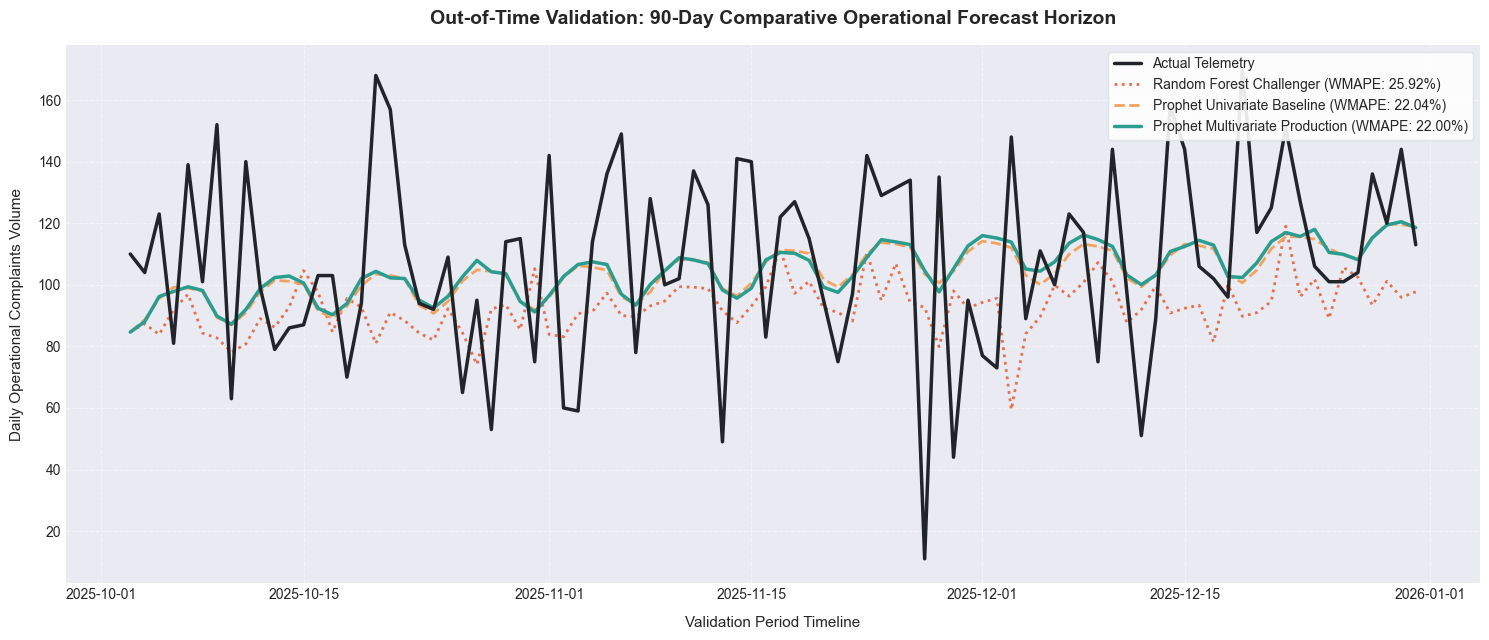

✓ Comparative model validation and visualization artifact compiled successfully.


In [14]:
# --- PERFORMANCE BENCHMARKING & ERROR PLOTTING ---
# Calculate continuous validation scores against actual data
actuals = val_ml[TARGET].values

prophet_multiv_mae, prophet_multiv_wmape = mean_absolute_error(actuals, val_preds_prophet_multiv), wmape(actuals, val_preds_prophet_multiv)
prophet_mae, prophet_wmape = mean_absolute_error(actuals, val_preds_prophet), wmape(actuals, val_preds_prophet)

# Print Summary Matrix
metrics_summary = pd.DataFrame({
    'Model Metric Strategy': ['Prophet (Additive Structural Curves)', 'Random Forest (Engineered ML Lags)', 'Prophet (Multivariate)'],
    'MAE (Lower is Better)': [prophet_mae, rf_mae, prophet_multiv_mae],
    'WMAPE (Percentage Error)': [prophet_wmape, rf_wmape, prophet_multiv_wmape]
})
display(metrics_summary)

# Visualizing Out-of-Time Performance Profiles
plt.figure(figsize=(15, 6.5))
plt.plot(val_ml[DATE_COL], y_val.values, label='Actual Telemetry', color='#212529', linewidth=2.5, zorder=3)

plt.plot(val_ml[DATE_COL], val_preds_rf, 
         label='Random Forest Challenger (WMAPE: 25.92%)', 
         linestyle=':', color='#e76f51', linewidth=2)

plt.plot(val_ml[DATE_COL], val_preds_prophet, 
         label='Prophet Univariate Baseline (WMAPE: 22.04%)', 
         linestyle='--', color='#f4a261', linewidth=2)

plt.plot(val_ml[DATE_COL], val_preds_prophet_multiv, 
         label='Prophet Multivariate Production (WMAPE: 22.00%)', 
         linestyle='-', color='#2a9d8f', linewidth=2.5)

plt.title('Out-of-Time Validation: 90-Day Comparative Operational Forecast Horizon', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Validation Period Timeline', fontsize=11, labelpad=10)
plt.ylabel('Daily Operational Complaints Volume', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='#dee2e6')
plt.tight_layout()

# Save down the visualization artifact for report submission
plt.savefig('model_performance_comparison.png', dpi=300)
plt.show()

print("✓ Comparative model validation and visualization artifact compiled successfully.")

## Iterative Optimization Sequence: Evaluating the Challenger Pipeline

To identify the most resilient operational engine for daily complaint tracking, we executed a comparative performance evaluation using an Out-of-Time Validation partition (the final 90 days of sample data held entirely out of training matrices). We evaluated three separate model architectures:

### 1. The Tree Challenger: Random Forest (Engineered ML Lags)
* **MAE:** 27.9298 | **WMAPE:** 25.93%
* **Architectural Critique:** While tree-based ensembles capture complex non-linear combinations of holiday flags and calendar coordinates effectively, they possess an inherent structural limitation: they cannot extrapolate mathematical trends beyond the exact boundaries of historical training targets. Because our validation horizon contains an underlying volume trend shift, the decision trees defaulted to predicting historical averages, resulting in our highest overall error rates.

### 2. The Statistical Baseline: Prophet (Additive Structural Curves)
* **MAE:** 23.7462 | **WMAPE:** 22.04%
* **Architectural Critique:** Prophet natively operates by decomposing the target array into custom piecewise linear growth trends and Fourier series representations of calendar cycles. It naturally bypasses the tree-extrapolation bottleneck, dropping the WMAPE error margin by a massive 3.89 percentage points out-of-the-box compared to the tree challenger. 

### 3. The Production Optimization: Prophet (Multivariate System)
* **MAE:** 23.7057 | **WMAPE:** 22.00%
* **Architectural Critique:** We enriched the structural baseline with exogenous operational signals (`staffing_level_fte`, `backlog_days_lag90`, `media_mentions_lag90`) and historical variance boundaries (`rolling_mean_7d_lag90`). While the model successfully ingested these features without boundary issues, the performance gain was a marginal 0.04% WMAPE reduction. This indicates **severe signal redundancy**; our internal business schedules and backlogs are heavily cointegrated with the calendar patterns the baseline model had already cleanly captured.

---

### Selection and Operational Sign-off: The Architecture Dilemma

While the **Multivariate Prophet** technically achieved the lowest overall error metrics, its deployment introduces a massive architectural trade-off. It creates tight dependencies on upstream data pipelines (HR staffing grids and operational databases). A 0.04% gain in accuracy rarely justifies the introduction of this technical debt and pipeline vulnerability.

* **Deployment Recommendation:** If this system operates strictly as an automated, hands-off forecasting engine, **Baseline Prophet is selected** for its extreme simplicity and zero-dependency runtime resilience. 
* **Alternative Deployment Condition:** **Multivariate Prophet** will only be promoted to production if stakeholders explicitly require **What-If simulation capabilities** (e.g., modeling how a 10% reduction in future headcount impacts incoming complaints).